# Demo — Detección de respiración por WiFi (CSI)

Una persona **quieta** que respira imprime una oscilación lenta (~0.2–0.4 Hz) en la
amplitud del CSI. Aquí lo mostramos de principio a fin sobre **datos sintéticos con
verdad conocida**: generar → limpiar → estimar → visualizar.

> Sustituir `generate_breathing(...)` por una captura real del ESP32 el día 16 no
> cambia nada más del notebook: la fuente de datos es lo único que varía.

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt

# Permite importar src/ tanto si se ejecuta desde notebooks/ como desde la raiz.
ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(".")
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.synth_csi import generate_breathing, generate_window
from src.preprocess import drop_null_subcarriers, lowpass
from src.breathing import estimate_breathing

fs = 100.0          # paquetes/s
BPM_REAL = 14.0     # respiraciones/min inyectadas (la "verdad")
SNR_DB = 22.0       # SNR moderado, no de laboratorio
DUR_S = 60          # ventana de 60 s (la respiracion es lenta -> ventana larga)
rng = np.random.default_rng(7)

def limpiar(csi):
    """CSI complejo -> amplitud limpia: quita nulas y filtra a la banda lenta."""
    amp, keep = drop_null_subcarriers(np.abs(csi))
    return lowpass(amp, fs=fs, fc=1.0), keep   # fc=1 Hz aisla movimiento/respiracion

def espectro(amp, fs=fs, zero_pad=4, band=(0.12, 0.55)):
    """Espectro combinado (ponderado por subportadora) para dibujar, en Hz."""
    x = amp - amp.mean(axis=0, keepdims=True)
    nfft = x.shape[0] * zero_pad
    freqs = np.fft.rfftfreq(nfft, d=1 / fs)
    P = np.abs(np.fft.rfft(x, n=nfft, axis=0)) ** 2
    m = (freqs >= band[0]) & (freqs <= band[1])
    w = P[m].max(axis=0) / (P[m].mean(axis=0) + 1e-12)
    w /= w.sum() + 1e-12
    return freqs, P @ w

## 1 · Generar dos capturas y estimar

Una con una persona respirando a **14 rpm** y otra de **habitación vacía**, ambas al
mismo SNR. El estimador debe clavar los 14 en la primera y **negarse** (confianza baja)
en la segunda.

In [2]:
n = int(DUR_S * fs)
csi_resp = generate_breathing(bpm=BPM_REAL, n_packets=n, fs=fs, snr_db=SNR_DB, rng=rng)
csi_vacio = generate_window(label=0, n_packets=n, snr_db=SNR_DB, rng=rng)

amp_resp, keep = limpiar(csi_resp)
amp_vacio, _ = limpiar(csi_vacio)

bpm_est, conf = estimate_breathing(amp_resp, fs=fs, combine="weighted")
bpm_vac, conf_vac = estimate_breathing(amp_vacio, fs=fs, combine="weighted")

UMBRAL = 2.0
print(f"Respirando -> {bpm_est:5.1f} rpm (real {BPM_REAL:.0f})  | confianza {conf:4.1f}"
      f"  -> {'DETECTA' if conf > UMBRAL else 'no detecta'}")
print(f"Vacio      -> {bpm_vac:5.1f} rpm            | confianza {conf_vac:4.1f}"
      f"  -> {'DETECTA' if conf_vac > UMBRAL else 'no detecta'}")

Respirando ->  14.0 rpm (real 14)  | confianza  9.5  -> DETECTA
Vacio      ->  22.8 rpm            | confianza  1.3  -> no detecta


## 2 · La foto

Cuatro vistas de la misma captura:
1. **Waterfall** — amplitud (subportadora × tiempo); se ve la ondulación periódica del pecho.
2. **Traza temporal** — la subportadora que más respira, oscilando en el tiempo.
3. **Espectro** — el pico en la banda respiratoria, con el BPM estimado en grande.
4. **Vacío** — mismo espectro sin nadie: plano, sin pico → el sistema no alucina.

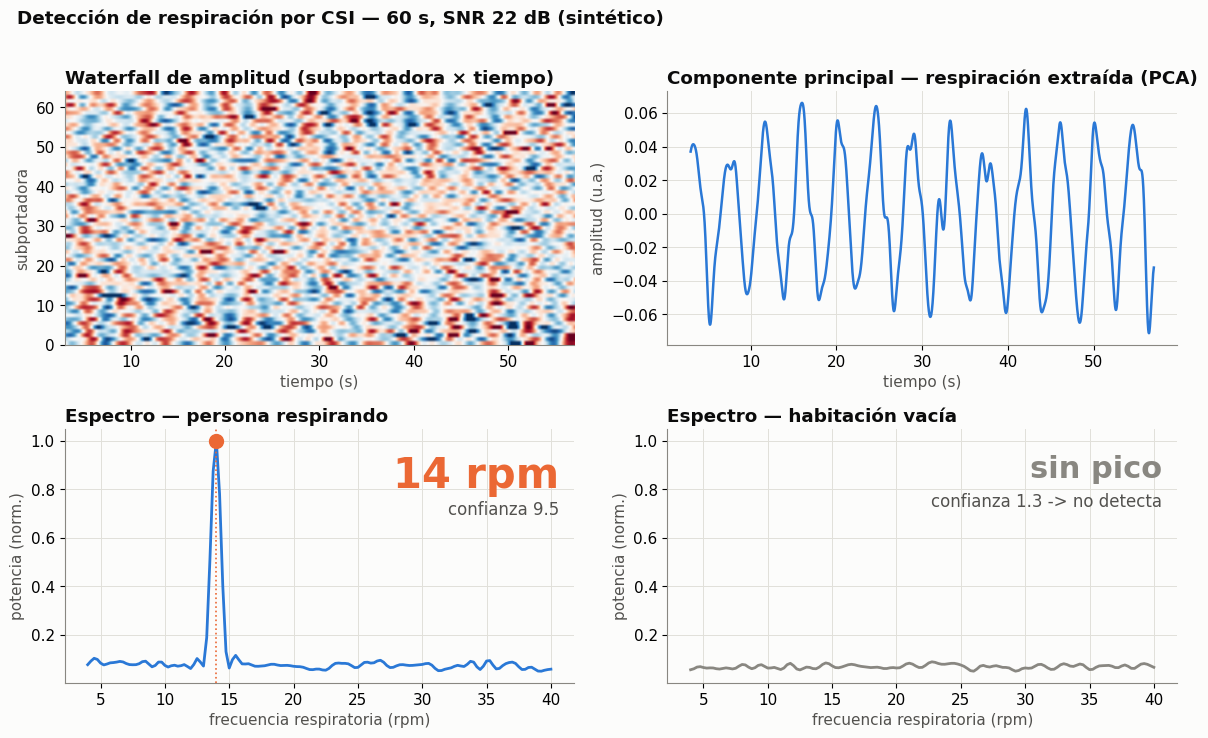

In [3]:
# --- paleta ---
BLUE, ORANGE, MUT = "#2a78d6", "#eb6834", "#898781"
SURF, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e1e0d9"
plt.rcParams.update({"font.family": "sans-serif", "font.size": 11,
                     "axes.edgecolor": MUT, "axes.linewidth": 0.8})

t = np.arange(n) / fs
c0, c1 = int(3 * fs), int((DUR_S - 3) * fs)       # recorte de transitorios de borde
amp_disp = lowpass(amp_resp, fs=fs, fc=0.5)       # filtro de display mas agresivo

fr, P_resp = espectro(amp_resp)
_, P_vacio = espectro(amp_vacio)
esc = P_resp.max() + 1e-12                         # escala comun para comparar alturas
bpm_axis = fr * 60.0
sel = (bpm_axis >= 4) & (bpm_axis <= 40)           # rango de dibujo (rpm)

fig, ax = plt.subplots(2, 2, figsize=(12, 7.5), facecolor=SURF)
for a in ax.ravel():
    a.set_facecolor(SURF)
    for s in ("top", "right"):
        a.spines[s].set_visible(False)

# (a) waterfall: dato "crudo" (media quitada), escala global robusta.
zc = (amp_disp - amp_disp.mean(0))[c0:c1]
vlim = np.percentile(np.abs(zc), 99) + 1e-12
ax[0, 0].imshow(zc.T, aspect="auto", origin="lower", cmap="RdBu_r",
                vmin=-vlim, vmax=vlim, extent=[c0 / fs, c1 / fs, 0, zc.shape[1]])
ax[0, 0].set_title("Waterfall de amplitud (subportadora × tiempo)", color=INK,
                   fontweight="bold", loc="left")
ax[0, 0].set_xlabel("tiempo (s)", color=INK2); ax[0, 0].set_ylabel("subportadora", color=INK2)

# (b) componente principal (SVD) = forma de onda respiratoria extraida.
# El PCA sobre subportadoras encuentra el patron temporal coherente (la
# respiracion) y rechaza el ruido incoherente -> sinusoide limpia.
Xc = amp_resp[c0:c1] - amp_resp[c0:c1].mean(0)
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
pc1 = U[:, 0] * S[0]
ax[0, 1].plot(t[c0:c1], pc1, color=BLUE, linewidth=1.8)
ax[0, 1].set_title("Componente principal — respiración extraída (PCA)", color=INK,
                   fontweight="bold", loc="left")
ax[0, 1].set_xlabel("tiempo (s)", color=INK2); ax[0, 1].set_ylabel("amplitud (u.a.)", color=INK2)
ax[0, 1].grid(True, color=GRID, linewidth=0.7); ax[0, 1].set_axisbelow(True)

# (c) espectro respirando: pico + BPM en grande
ax[1, 0].plot(bpm_axis[sel], (P_resp / esc)[sel], color=BLUE, linewidth=2)
ip = int(np.argmax(P_resp[sel]))
bpm_pico = bpm_axis[sel][ip]
ax[1, 0].plot(bpm_pico, (P_resp / esc)[sel][ip], "o", color=ORANGE, markersize=10, zorder=5)
ax[1, 0].axvline(bpm_pico, color=ORANGE, linestyle=":", linewidth=1.2)
ax[1, 0].text(0.97, 0.9, f"{bpm_est:.0f} rpm", transform=ax[1, 0].transAxes,
              ha="right", va="top", fontsize=30, fontweight="bold", color=ORANGE)
ax[1, 0].text(0.97, 0.72, f"confianza {conf:.1f}", transform=ax[1, 0].transAxes,
              ha="right", va="top", fontsize=12, color=INK2)
ax[1, 0].set_title("Espectro — persona respirando", color=INK, fontweight="bold", loc="left")
ax[1, 0].set_xlabel("frecuencia respiratoria (rpm)", color=INK2)
ax[1, 0].set_ylabel("potencia (norm.)", color=INK2)
ax[1, 0].grid(True, color=GRID, linewidth=0.7); ax[1, 0].set_axisbelow(True)

# (d) espectro vacio: mismo eje, plano
ax[1, 1].plot(bpm_axis[sel], (P_vacio / esc)[sel], color=MUT, linewidth=2)
ax[1, 1].text(0.97, 0.9, "sin pico", transform=ax[1, 1].transAxes,
              ha="right", va="top", fontsize=22, fontweight="bold", color=MUT)
ax[1, 1].text(0.97, 0.75, f"confianza {conf_vac:.1f} -> no detecta",
              transform=ax[1, 1].transAxes, ha="right", va="top", fontsize=12, color=INK2)
ax[1, 1].set_ylim(ax[1, 0].get_ylim())            # misma escala que (c): comparacion honesta
ax[1, 1].set_title("Espectro — habitación vacía", color=INK, fontweight="bold", loc="left")
ax[1, 1].set_xlabel("frecuencia respiratoria (rpm)", color=INK2)
ax[1, 1].set_ylabel("potencia (norm.)", color=INK2)
ax[1, 1].grid(True, color=GRID, linewidth=0.7); ax[1, 1].set_axisbelow(True)

fig.suptitle("Detección de respiración por CSI — 60 s, SNR 22 dB (sintético)",
             color=INK, fontweight="bold", x=0.02, ha="left")
fig.tight_layout(rect=[0, 0, 1, 0.97])
os.makedirs(os.path.join(ROOT, "figures"), exist_ok=True)
fig.savefig(os.path.join(ROOT, "figures", "demo_respiracion.png"), dpi=140,
            facecolor=SURF, bbox_inches="tight")
plt.show()

## Qué demuestra esto

- El CSI crudo **parece ruido** (waterfall), pero la respiración está dentro.
- **PCA** sobre las subportadoras extrae la forma de onda respiratoria (rechaza el
  ruido incoherente); la **FFT** con combinación ponderada da la frecuencia → **14 rpm**.
- La **confianza** (pico/media en banda) distingue *respira* (9.5) de *vacío* (1.3):
  el sistema **se niega** cuando no hay señal, en vez de inventar un número.

**Día 16:** sustituir `generate_breathing(...)` por `cargar_amplitudes("data/raw/…csv")`
de una captura real y volver a correr. Todo lo demás queda igual.

> Límite honesto: a SNR < ~15 dB (probable a través de pared) la detección cae. Ahí
> se mide el SNR real y se decide software (ventana más larga) o front-end multi-antena.